# Imaginary noise buildup in the SCF cycle
In this notebook we try to explore the noise buildup that arises as a consequence of the use of `eig` instead of `eigh` when using a complex datatype

In [1]:
from pyscf import gto, scf, mp
import numpy as np
from py_mods.src.MP2.CSMP2 import CS_MP2
from py_mods.src.SCF.CSRHF import CS_RHF
from py_mods.src.SCF.external import RHF_context_from_pyscf
from py_mods.src.SCF.plot_utilities import plot_map

In [2]:
pyscf_args = {
    "atom": "He 0 0 0",
    "spin": 0,
    "charge": 0,
    "basis": f"cc-pv5z",
}

for iteration in range(1,25):
    mol = gto.M(**pyscf_args)
    mol.verbose = 0

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    RHF_cxt.verbose = False
    RHF_cxt.conv_type = None
    RHF_cxt.max_iter = iteration
    # RHF_cxt.theta = 0.1
    RHF_res = CS_RHF(RHF_cxt)
    # print('Number of orbitals is: ', len(RHF_res.X))
    mp_results = CS_MP2(RHF_res)

    MP2_error = (mymp.e_tot - mp_results.E_MP2)
    print(f'\nAt iteration {iteration}:')
    print('He/aug-cc-pvqz MP2 error:', MP2_error)
    print(f"max of imag part of coefficient matrix is {np.max(RHF_res.C_munu.imag):5e}")
    print('Norm of the imaginay part of the density matrix is:', np.linalg.norm(RHF_res.P.imag))


At iteration 1:
He/aug-cc-pvqz MP2 error: (-2.852535096172178+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 2:
He/aug-cc-pvqz MP2 error: (-0.11153323928811298+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 3:
He/aug-cc-pvqz MP2 error: (0.0014493350524191762-5.1590620837915656e-20j)
max of imag part of coefficient matrix is 1.104704e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 4:
He/aug-cc-pvqz MP2 error: (-4.178697537282616e-05+2.2540973668532576e-22j)
max of imag part of coefficient matrix is 3.985491e-03
Norm of the imaginay part of the density matrix is: 0.0

At iteration 5:
He/aug-cc-pvqz MP2 error: (-2.821925281004667e-06+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 6:
He/aug-cc-pvqz MP2 error: (-3.70839239

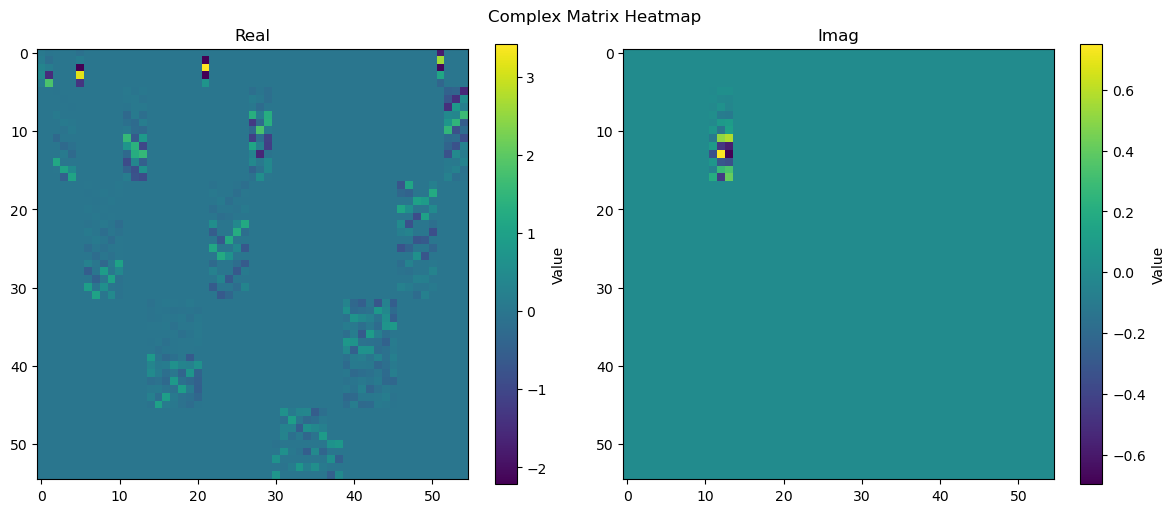

max of imag part of coefficient matrix is 7.497863e-01


In [3]:
plot_map(RHF_res.C_munu)
print(f"max of imag part of coefficient matrix is {np.max(RHF_res.C_munu.imag):5e}")

In [4]:
for iteration in range(1,18):
    mol = gto.M(**pyscf_args)
    mol.verbose = 0

    mf = scf.RHF(mol)

    e_He = mf.kernel()
    e_elec = mf.energy_elec()

    mymp = mp.RMP2(mf).run()  # this is UMP2

    # implementation and calculation
    RHF_cxt = RHF_context_from_pyscf(**pyscf_args)
    RHF_cxt.verbose = False
    RHF_cxt.conv_type = None
    RHF_cxt.max_iter = iteration
    # RHF_cxt.theta = 0.1
    RHF_res = CS_RHF(RHF_cxt)
    # print('Number of orbitals is: ', len(RHF_res.X))
    mp_results = CS_MP2(RHF_res)

    MP2_error = (mymp.e_tot - mp_results.E_MP2)
    print(f'\nAt iteration {iteration}:')
    print('He/aug-cc-pvqz MP2 error:', MP2_error)
    print(f"max of imag part of coefficient matrix is {np.max(RHF_res.C_munu.imag):5e}")
    print('Norm of the imaginay part of the density matrix is:', np.linalg.norm(RHF_res.P.imag))


At iteration 1:
He/aug-cc-pvqz MP2 error: (-2.8525350961721783+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 2:
He/aug-cc-pvqz MP2 error: (-0.11153323928811121+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 3:
He/aug-cc-pvqz MP2 error: (0.0014493350524200643-5.1590620837915656e-20j)
max of imag part of coefficient matrix is 1.104704e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 4:
He/aug-cc-pvqz MP2 error: (-4.178697537282616e-05+2.2540973668532576e-22j)
max of imag part of coefficient matrix is 3.985491e-03
Norm of the imaginay part of the density matrix is: 0.0

At iteration 5:
He/aug-cc-pvqz MP2 error: (-2.821925278784221e-06+0j)
max of imag part of coefficient matrix is 0.000000e+00
Norm of the imaginay part of the density matrix is: 0.0

At iteration 6:
He/aug-cc-pvqz MP2 error: (-3.7083923

In [5]:
np.linalg.norm(RHF_res.error)

np.float64(1.4632339913324215e-11)

In [6]:
plot_map(RHF_iter_2.C_munu.T @ RHF_iter_2.C_munu )
print(f"max of imag part of coefficient matrix is {np.max(RHF_iter_2.C_munu.imag):5e}")

NameError: name 'RHF_iter_2' is not defined